# Orthogonality, permutation nulls, and J vs J_KS tests

This notebook reconstructs:
- Attractor–eigenvector alignment for the empirical connectome
- A symmetry-preserving permutation null for the alignment
- Off-diagonal cosine similarity between J and its Kanter–Sompolinsky analog J_KS, plus a matched null

It mirrors the analyses from `orthogonality.ipynb` that were lost.



In [1]:
# Imports and setup
import numpy as np
import pandas as pd
import seaborn as sns
from glob import glob
from matplotlib import pyplot as plt
from nilearn.connectome import ConnectivityMeasure
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

sns.set(style='white')

import os, sys
sys.path.append('..')
from connattractor import network

# Reproducibility
GLOBAL_RNG = np.random.default_rng(42)


/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# load Essen timeseries data and scrub resting state data
_fd_thr = 0.15
_perc_scrub_thr = 0.5
all_ts = []
root_dir = '../data_in/ex_timeseries/'
for f in glob(root_dir + 'essen-*.tsv'):  # change to bochum-*.tsv for replication with the Bochum dataset
    path, filename = os.path.split(f)
    ts = pd.read_csv(f, sep='\t').iloc[:, 1:].values
    ts = StandardScaler().fit_transform(ts)
    fd = pd.read_csv(path + '/FD_' + os.path.splitext(filename)[0] + '.txt', sep=',').values.flatten()
    fd = np.hstack(([0], fd))
    if np.sum(fd>_fd_thr)/len(fd) < _perc_scrub_thr:
        all_ts.append(ts[fd<_fd_thr])
    else:
        print('perc. scrubbed:', np.sum(fd>_fd_thr)/len(fd))
len(all_ts)

perc. scrubbed: 0.5103448275862069
perc. scrubbed: 0.503448275862069


47

np.float64(0.3518215546978733)

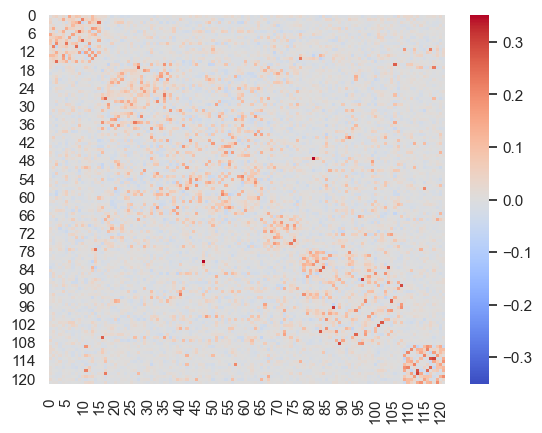

In [3]:
from connattractor import network
from nilearn.connectome import ConnectivityMeasure
# fcHNN solution
correlation_measure = ConnectivityMeasure(kind='partial correlation',  vectorize=False, discard_diagonal=False) # uses Ledoit-Wolf estimator
correlation_measure.fit_transform(all_ts)
J_true = correlation_measure.mean_
J_true = J_true - np.diag(np.diag(J_true)) # remove self-connections, see Kanter & Sompolinsky 1987
N = J_true.shape[0]

# plot J_true
sns.heatmap(J_true, vmin=-J_true.max(), vmax=J_true.max(), cmap='coolwarm')
J_true.max()


In [4]:


# Deterministic attractor extraction
_beta_ = 0.08

def extract_collapsed_attractors(J, num_starts, beta=_beta_, seed=42, tol=0.99):
    rng = np.random.default_rng(seed)
    hop = network.Hopfield(J, scale=True)
    counts = {}
    for _ in range(num_starts):
        res = hop.update(np.tanh(rng.normal(0, 1, J.shape[0])), beta=beta, num_iter=1000)
        if res[1] < 1000:
            s = tuple(np.round(res[0], 1))
            counts[s] = counts.get(s, 0) + 1
    A = np.array([k for k, v in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)])
    # collapse sign-duplicates by correlation
    coll = []
    for a in A:
        keep = True
        for b in coll:
            if np.abs(np.corrcoef(a, b)[0, 1]) > tol:
                keep = False
                break
        if keep:
            coll.append(a)
    return np.array(coll)

A_t = extract_collapsed_attractors(J_true, num_starts=1000, beta=_beta_, seed=42)
A_t.shape


(22, 122)

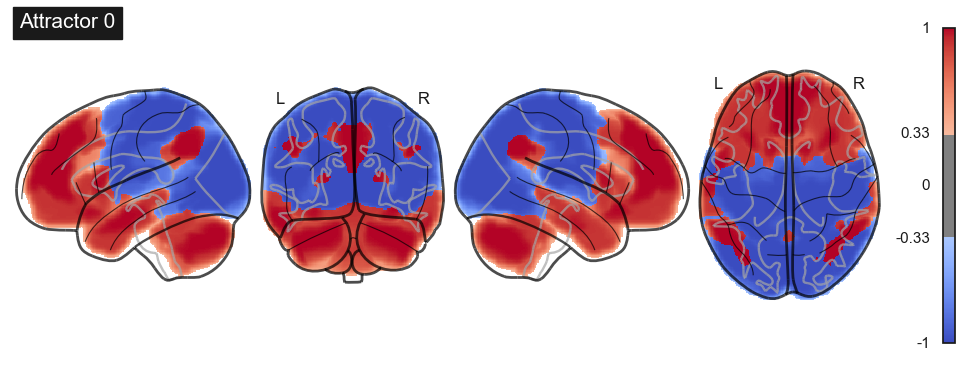

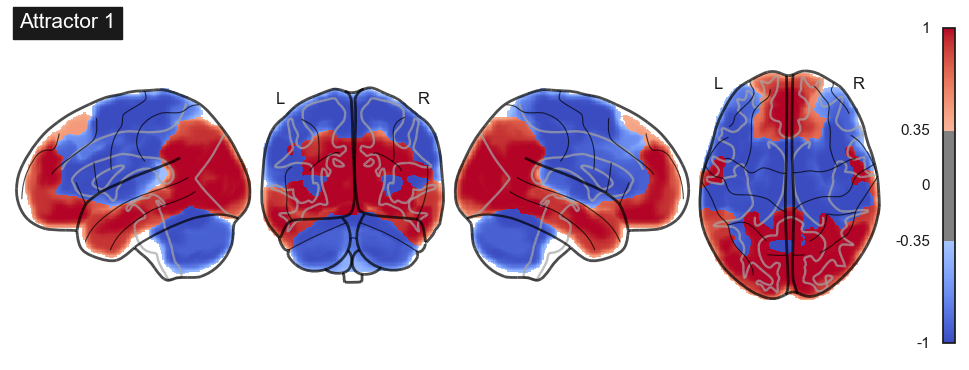

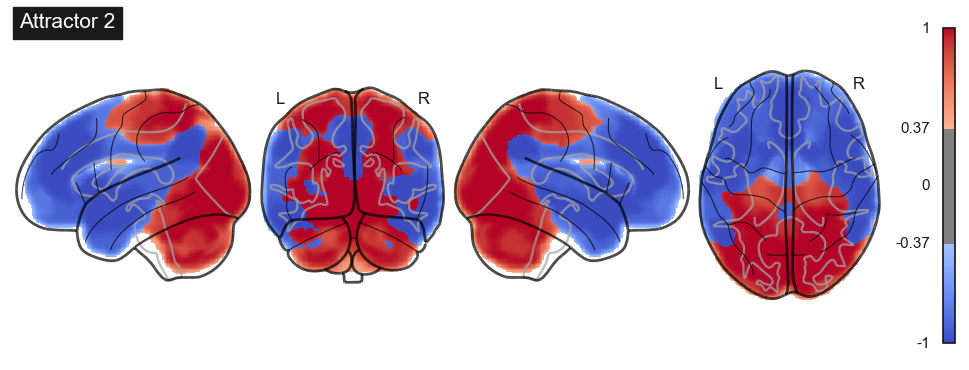

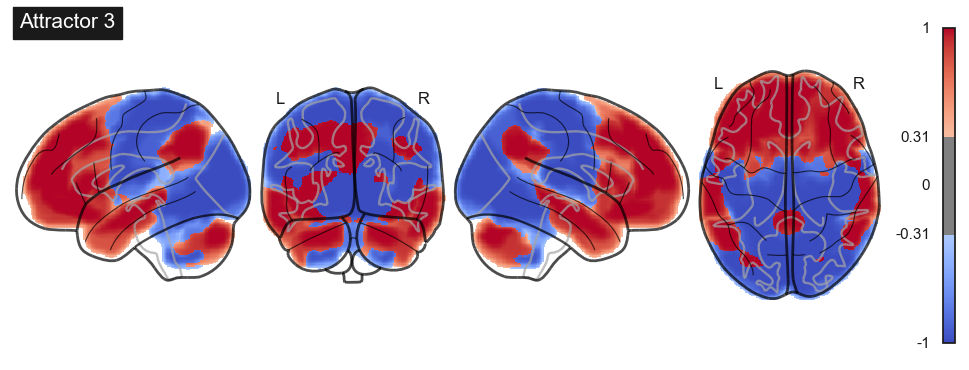

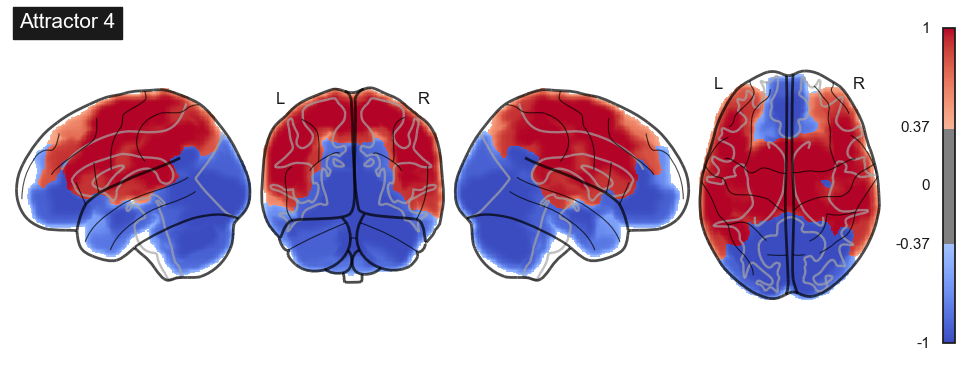

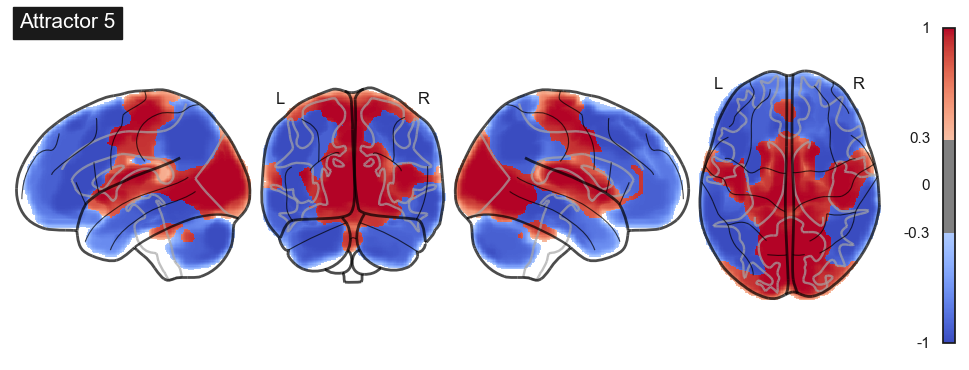

In [5]:
for i, attractor in enumerate(A_t):
    ax = network.State(attractor).plot(title=f"Attractor {i}")
    plt.show()
    if i > 4:
        break


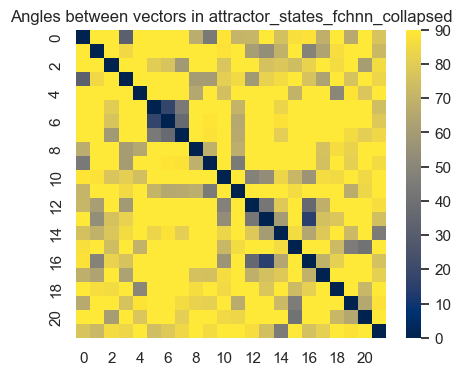

In [6]:
def angle_between(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

# Compute angles between vectors in attractor_states_fchnn_collapsed
angles_fchnn = np.zeros((len(A_t), len(A_t)))
for i in range(len(A_t)):
    for j in range(len(A_t)):
        if i != j:
            angles_fchnn[i, j] = angle_between(A_t[i], A_t[j])

# Plot the angles for attractor_states_fchnn_collapsed
plt.figure(figsize=(5, 4))
sns.heatmap(np.abs(angles_fchnn), cmap='cividis', annot=False, fmt=".0f", annot_kws={"size": 8}, vmin=0, vmax=90)
plt.title('Angles between vectors in attractor_states_fchnn_collapsed')
plt.show()

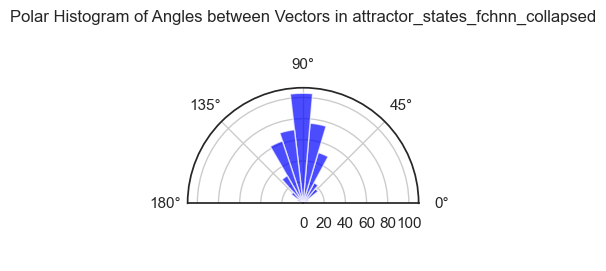

In [26]:
# Plot the angles as a polar histogram
plt.figure(figsize=(3, 3))
ax = plt.subplot(111, polar=True)
angles_no_self = angles_fchnn[~np.eye(angles_fchnn.shape[0], dtype=bool)]
ax.hist(np.deg2rad(angles_no_self.flatten()), bins=12, color='blue', alpha=0.7)
ax.set_title('Polar Histogram of Angles between Vectors in attractor_states_fchnn_collapsed')
ax.set_xlim(0, np.pi)  # Only show the upper half of the circle
plt.show()

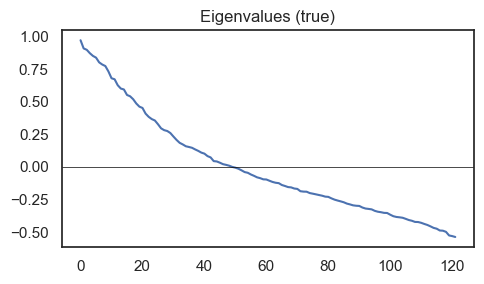

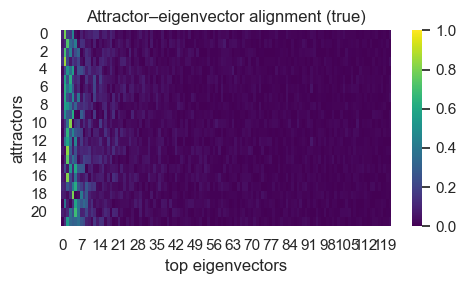

In [37]:
# Eigen-decomposition and alignment (true)
lam_t, V_t = np.linalg.eigh(J_true)
idx_t = np.argsort(lam_t)[::-1]
lam_t = lam_t[idx_t]
V_t = V_t[:, idx_t]

# Normalize rows/cols
def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    nrm = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    return X / nrm

A_tn = normalize_rows(A_t)
# Alignment matrix between attractors and leading eigenvectors (use all N to allow later slicing)
Align_true = np.abs(A_tn @ V_t[:, :N])

plt.figure(figsize=(5, 3))
plt.plot(lam_t, '-')
plt.title('Eigenvalues (true)')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout(); 
plt.show()

plt.figure(figsize=(5, 3))
sns.heatmap(Align_true, vmin=0, vmax=1, cmap='viridis')
plt.title('Attractor–eigenvector alignment (true)')
plt.xlabel('top eigenvectors'); plt.ylabel('attractors')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout(); 
plt.show()



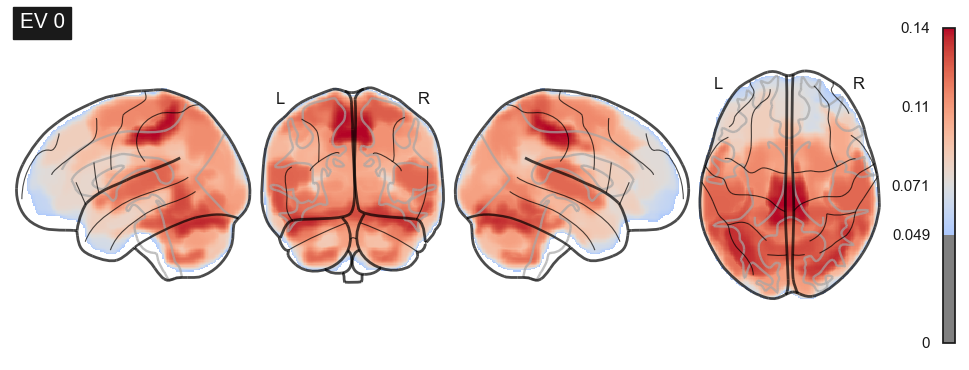

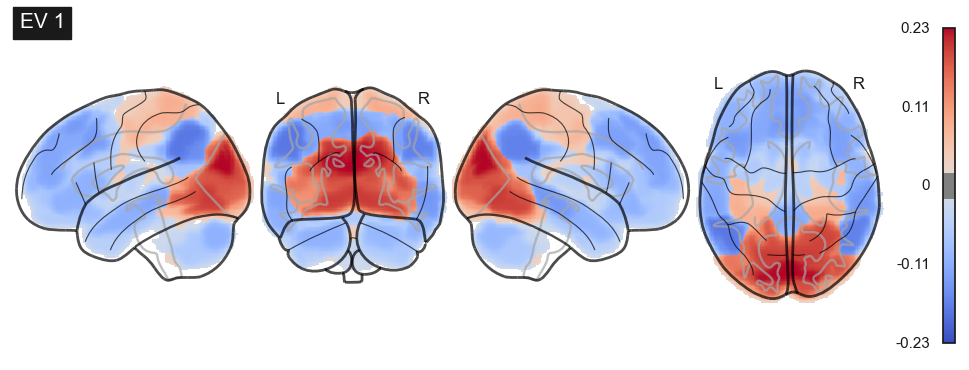

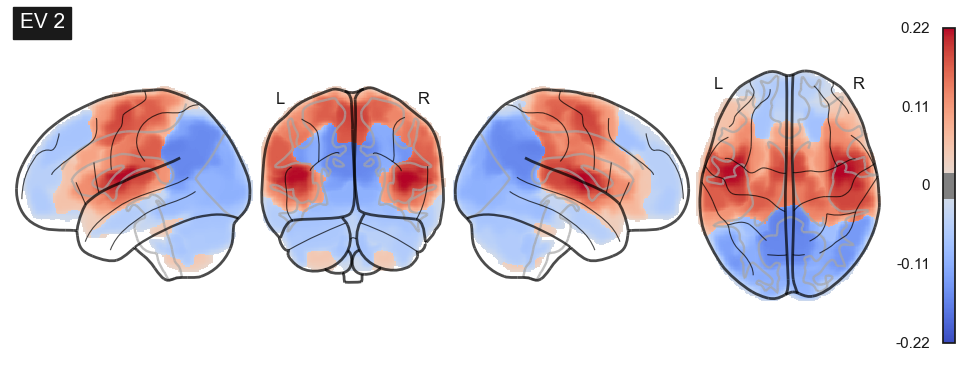

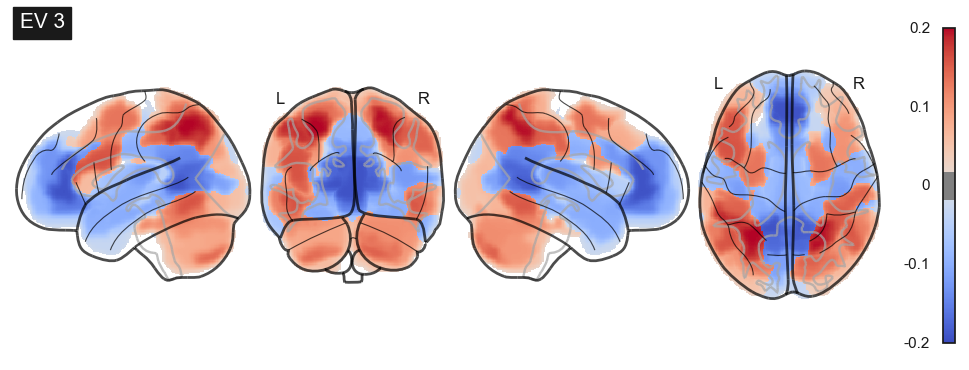

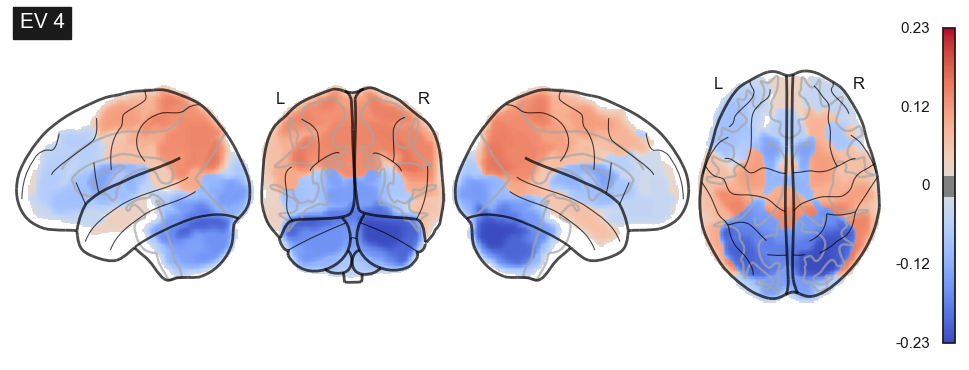

In [9]:
for i in range(V_t.shape[1]):
    ax = network.State(V_t[:, i]).plot(title=f"EV {i}")
    plt.show()
    if i > 3:
        break

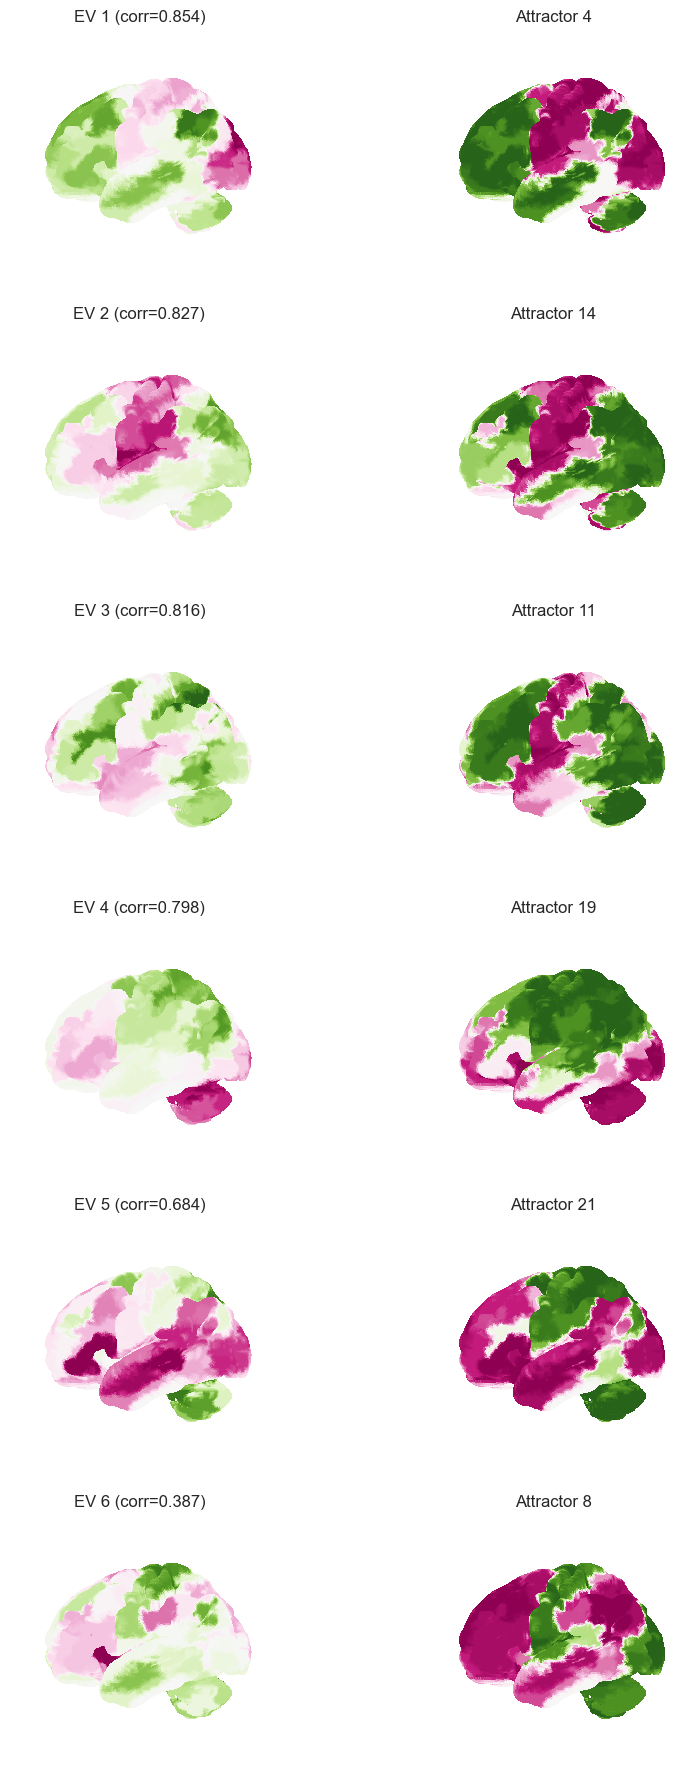

In [10]:
# Surface plots: first 4 eigenvector→attractor pairs (true), overlay-only
import numpy as np
from nilearn import datasets, surface, plotting
from matplotlib import pyplot as plt

# Fetch fsaverage surface
fsavg = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
surf = surface.load_surf_mesh("../data_in/surf/full_brain_left.surf.gii")
bg_map = None

# Normalize for signed correlation
A_tn = A_t / (np.linalg.norm(A_t, axis=1, keepdims=True))
Vn = V_t / (np.linalg.norm(V_t, axis=0, keepdims=True))

# How many pairs (skip the first eigenvector)
num_pairs = min(6, Align_true.shape[1] - 1)
if num_pairs <= 0:
    raise RuntimeError('Not enough eigenvectors to plot (need at least 2).')

fig, axs = plt.subplots(num_pairs, 2, subplot_kw={'projection': '3d'}, figsize=(10, 3.0 * num_pairs))
if num_pairs == 1:
    axs = np.array([axs])

for r in range(num_pairs):
    j = r + 1  # skip first EV
    i = int(np.argmax(Align_true[:, j]))
    corr = float(A_tn[i] @ Vn[:, j])

    # Eigenvector (flip sign to match attractor)
    v = V_t[:, j]
    if corr < 0:
        v = -v
    img_v = network.State(v).to_Nifti1Image()
    tex_v = surface.vol_to_surf(img_v, surf)
    plotting.plot_surf_stat_map(
        surf, tex_v, bg_map=bg_map, bg_on_data=False, hemi='left', colorbar=False,
        cmap='PiYG', threshold=0, figure=fig, axes=axs[r, 0], symmetric_cbar=True,
        vmin=-0.2, vmax=0.2, darkness=1,
    )
    axs[r, 0].set_title(f'EV {j} (corr={abs(corr):.3f})')

    # Attractor
    a = A_t[i]
    img_a = network.State(a).to_Nifti1Image()
    tex_a = surface.vol_to_surf(img_a, surf)
    plotting.plot_surf_stat_map(
        surf, tex_a, bg_map=bg_map, bg_on_data=False, hemi='left', colorbar=False,
        cmap='PiYG', threshold=0, figure=fig, axes=axs[r, 1], symmetric_cbar=True,
        vmin=-1, vmax=1, darkness=1,
    )
    axs[r, 1].set_title(f'Attractor {i+1}')

plt.tight_layout()
plt.show()



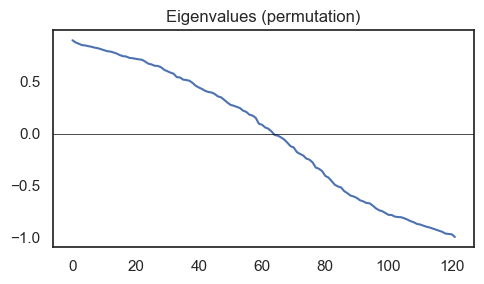

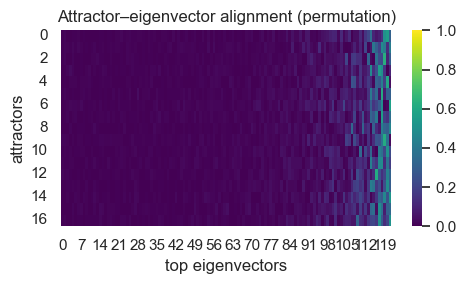

In [39]:
from scipy.fft import fft, ifft

# Permutation-based null for eigenvector–attractor alignment
triu_i, triu_j = np.triu_indices(N, k=1)

# For each permutation: permute symmetric off-diagonals, recompute eigenvectors and attractors, compute Align

def align_for_perm(seed, num_starts=200):
    rng = np.random.default_rng(seed)

    # Function to phase-randomize a time series
    def phase_randomize(ts):
        f_ts = fft(ts)
        n = len(ts)
        # Handle both even and odd length time series
        if n % 2 == 0:
            # Even length: exclude DC and Nyquist components
            random_phases = np.exp(1j * rng.uniform(0, 2 * np.pi, n // 2 - 1))
            f_ts[1:n // 2] *= random_phases
            f_ts[n // 2 + 1:] *= np.conj(random_phases)
        else:
            # Odd length: exclude DC component only
            random_phases = np.exp(1j * rng.uniform(0, 2 * np.pi, n // 2))
            f_ts[1:n // 2 + 1] *= random_phases
            f_ts[n // 2 + 1:] *= np.conj(random_phases)
        return np.real(ifft(f_ts))

    # Initialize connectivity measure
    conn_measure = ConnectivityMeasure(kind='partial correlation')

    # Phase randomize and calculate precision matrix for each participant
    for participant_ts in all_ts:
        randomized_ts = np.array([phase_randomize(participant_ts[:, i]) for i in range(participant_ts.shape[1])]).T
        Jp = conn_measure.fit_transform([randomized_ts])[0]
        Jp = Jp - np.diag(np.diag(Jp)) # remove self-connections, see Kanter & Sompolinsky 1987

    # eigenvectors
    lam_p, V_p = np.linalg.eigh(Jp)
    idx_p = np.argsort(lam_p)[::-1]
    lam_p = lam_p[idx_p]
    V_p = V_p[:, idx_p]
    # attractors
    A_p = extract_collapsed_attractors(Jp, num_starts=num_starts, beta=_beta_, seed=seed+1)
    if A_p.size == 0:
        return None, None, None
    A_pn = normalize_rows(A_p)
    Align_p = np.abs(A_pn @ V_p[:, :N])
    return Align_p, lam_p, A_p, V_p


# Run a single permutation
Align_p, lam_p, A_p, V_p = align_for_perm(seed=10)

# Plot the eigenvalues for the permutation
plt.figure(figsize=(5, 3))
plt.plot(lam_p, '-')
plt.title('Eigenvalues (permutation)')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Plot the eigenvector-attractor correlations for the permutation
plt.figure(figsize=(5, 3))
sns.heatmap(Align_p, vmin=0, vmax=1, cmap='viridis')
plt.title('Attractor–eigenvector alignment (permutation)')
plt.xlabel('top eigenvectors')
plt.ylabel('attractors')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()





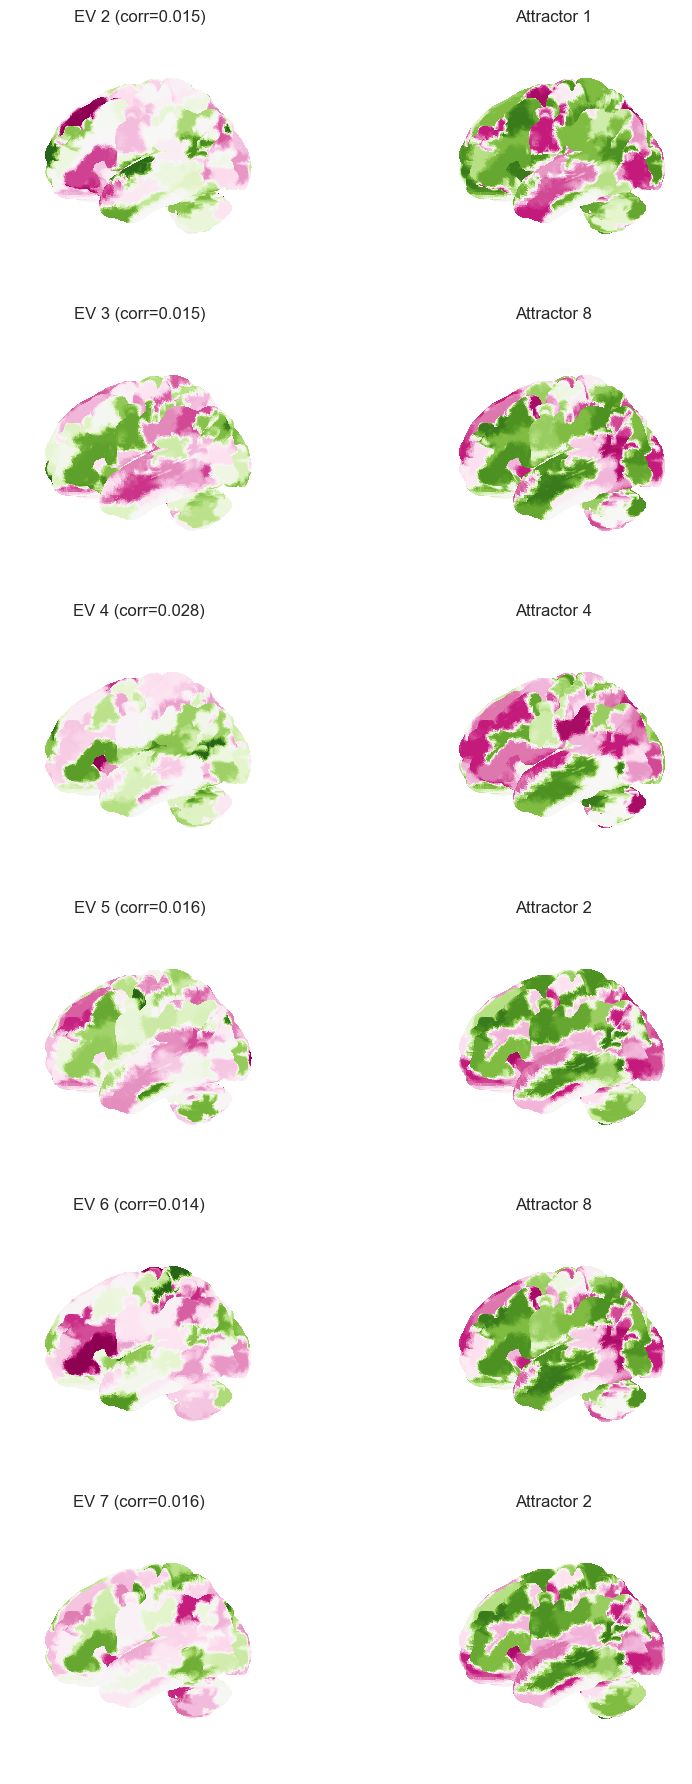

In [12]:
# Surface plots: first 4 eigenvector→attractor pairs (true), overlay-only
import numpy as np
from nilearn import datasets, surface, plotting
from matplotlib import pyplot as plt

# Fetch fsaverage surface
fsavg = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
surf = surface.load_surf_mesh("../data_in/surf/full_brain_left.surf.gii")
bg_map = None

# Normalize for signed correlation
A_pn = A_p / (np.linalg.norm(A_p, axis=1, keepdims=True))
Vpn = V_p / (np.linalg.norm(V_p, axis=0, keepdims=True))

# How many pairs (skip the first eigenvector)
num_pairs = min(6, Align_p.shape[1] - 1)
if num_pairs <= 0:
    raise RuntimeError('Not enough eigenvectors to plot (need at least 2).')

fig, axs = plt.subplots(num_pairs, 2, subplot_kw={'projection': '3d'}, figsize=(10, 3.0 * num_pairs))
if num_pairs == 1:
    axs = np.array([axs])

for r in range(num_pairs):
    j = r + 1  # skip first EV
    i = int(np.argmax(Align_p[:, j]))
    corr = float(A_pn[i] @ Vpn[:, j])

    # Eigenvector (flip sign to match attractor)
    v = V_p[:, j]
    if corr < 0:
        v = -v
    img_v = network.State(v).to_Nifti1Image()
    tex_v = surface.vol_to_surf(img_v, surf)
    plotting.plot_surf_stat_map(
        surf, tex_v, bg_map=bg_map, bg_on_data=False, hemi='left', colorbar=False,
        cmap='PiYG', threshold=0, figure=fig, axes=axs[r, 0], symmetric_cbar=True,
        vmin=-0.2, vmax=0.2, darkness=1,
    )
    axs[r, 0].set_title(f'EV {j+1} (corr={abs(corr):.3f})')

    # Attractor
    a = A_p[i]
    img_a = network.State(a).to_Nifti1Image()
    tex_a = surface.vol_to_surf(img_a, surf)
    plotting.plot_surf_stat_map(
        surf, tex_a, bg_map=bg_map, bg_on_data=False, hemi='left', colorbar=False,
        cmap='PiYG', threshold=0, figure=fig, axes=axs[r, 1], symmetric_cbar=True,
        vmin=-1, vmax=1, darkness=1,
    )
    axs[r, 1].set_title(f'Attractor {i+1}')

plt.tight_layout()
plt.show()



The eigenvectors with low eigenvalues have a larger alignment, but these are very often driven by noise, i.e. activation in just a few regions:

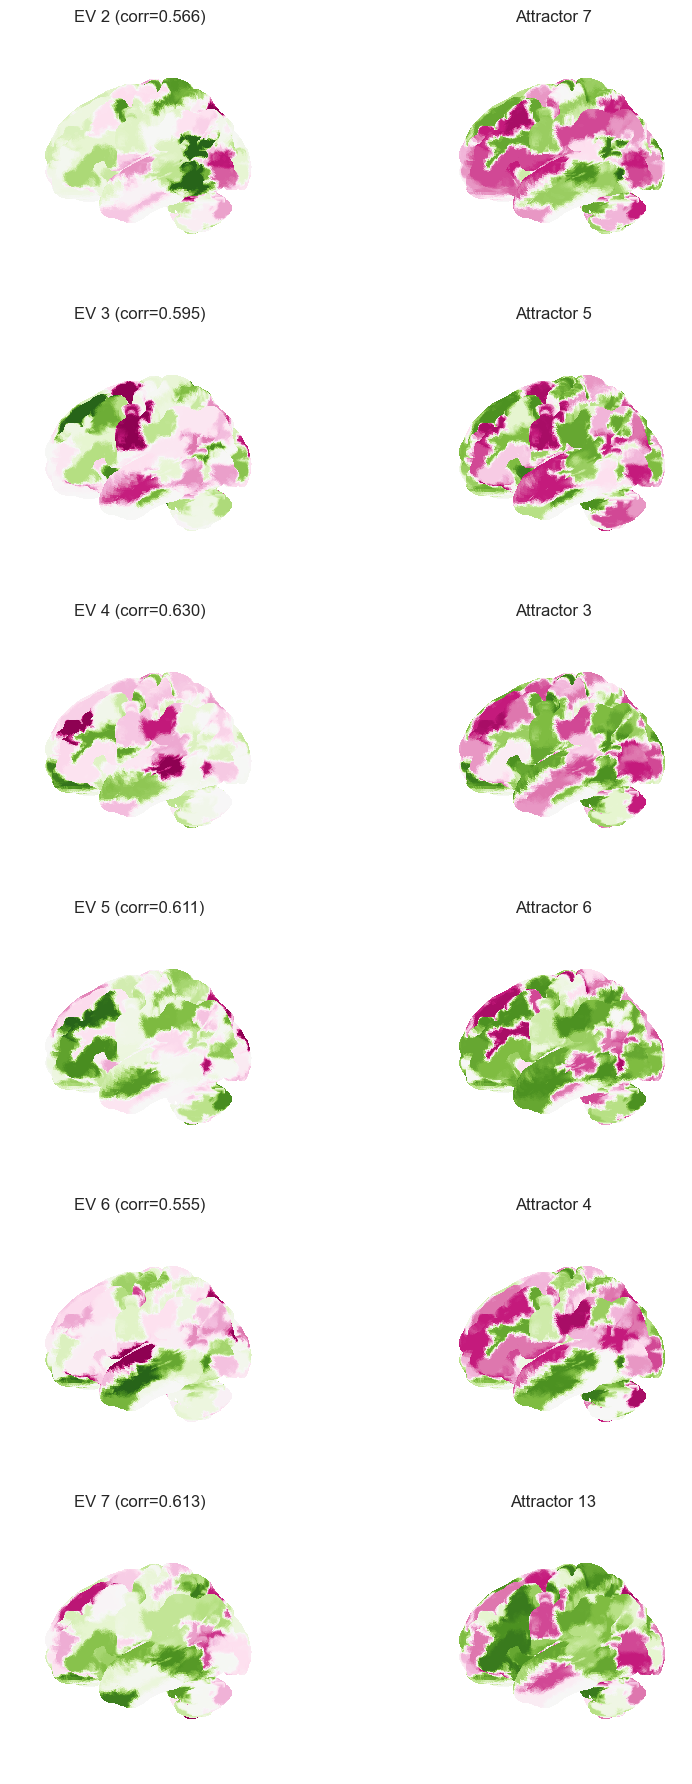

In [14]:
# Surface plots: first 4 eigenvector→attractor pairs (true), overlay-only
import numpy as np
from nilearn import datasets, surface, plotting
from matplotlib import pyplot as plt

# Fetch fsaverage surface
fsavg = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
surf = surface.load_surf_mesh("../data_in/surf/full_brain_left.surf.gii")
bg_map = None

# Normalize for signed correlation
A_pn = A_p / (np.linalg.norm(A_p, axis=1, keepdims=True))
Vpn = V_p / (np.linalg.norm(V_p, axis=0, keepdims=True))

# How many pairs (skip the first eigenvector)
num_pairs = min(6, Align_p.shape[1] - 1)
if num_pairs <= 0:
    raise RuntimeError('Not enough eigenvectors to plot (need at least 2).')

fig, axs = plt.subplots(num_pairs, 2, subplot_kw={'projection': '3d'}, figsize=(10, 3.0 * num_pairs))
if num_pairs == 1:
    axs = np.array([axs])

for r in range(num_pairs):
    j = r + 1  # skip first EV
    i = int(np.argmax(Align_p[:, -j]))
    corr = float(A_pn[i] @ Vpn[:, -j])

    # Eigenvector (flip sign to match attractor)
    v = V_p[:, -j]
    if corr < 0:
        v = -v
    img_v = network.State(v).to_Nifti1Image()
    tex_v = surface.vol_to_surf(img_v, surf)
    plotting.plot_surf_stat_map(
        surf, tex_v, bg_map=bg_map, bg_on_data=False, hemi='left', colorbar=False,
        cmap='PiYG', threshold=0, figure=fig, axes=axs[r, 0], symmetric_cbar=True,
        vmin=-0.2, vmax=0.2, darkness=1,
    )
    axs[r, 0].set_title(f'EV {j+1} (corr={abs(corr):.3f})')

    # Attractor
    a = A_p[i]
    img_a = network.State(a).to_Nifti1Image()
    tex_a = surface.vol_to_surf(img_a, surf)
    plotting.plot_surf_stat_map(
        surf, tex_a, bg_map=bg_map, bg_on_data=False, hemi='left', colorbar=False,
        cmap='PiYG', threshold=0, figure=fig, axes=axs[r, 1], symmetric_cbar=True,
        vmin=-1, vmax=1, darkness=1,
    )
    axs[r, 1].set_title(f'Attractor {i+1}')

plt.tight_layout()
plt.show()



In [15]:
# run all perms

num_perms = 1000
perm_results = Parallel(n_jobs=-1)(delayed(align_for_perm)(s) for s in range(num_perms))
Align_perm_list = [r[0] for r in perm_results if r[0] is not None]

/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, current

In [16]:
null_max_dists = []
for i_A, A in enumerate(Align_perm_list):
    null_max_dists.append([np.max(A[:, i_a]) for i_a in range(A.shape[1])])

null_max_dists = np.array(null_max_dists)
null_max_dists.shape

(1000, 122)

In [17]:
null_max_dists[:, 1].shape

(1000,)

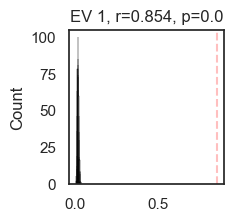

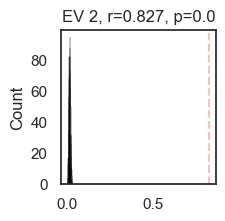

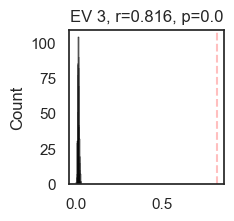

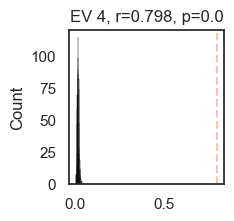

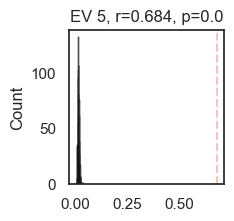

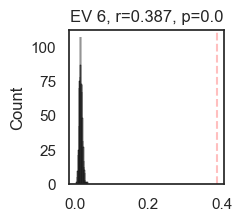

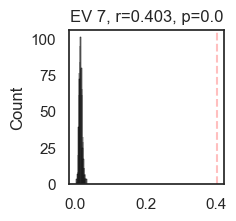

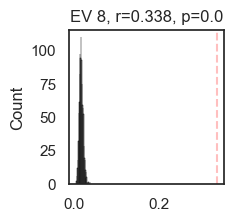

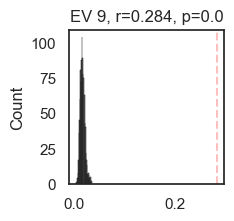

In [18]:
for i in range(1,10):
    plt.figure(figsize=(2, 2))
    sns.histplot(null_max_dists[:, i], bins=30, color='gray', edgecolor='black')
    plt.axvline(np.max(Align_true[:, i]), color='red', linestyle='--', alpha=0.25)
    plt.title(f'EV {i}, r={np.max(Align_true[:, i]):.3f}, p={np.sum(null_max_dists[:, i] >= np.max(Align_true[:, i])) / num_perms}')
    plt.show()



/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tspisak/src/connattractor/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, current

Off-diagonal cosine (true): 0.568
Null median [IQR]: -0.199 [-0.292, -0.085] (n=998)
p-value (null >= true): 0.001


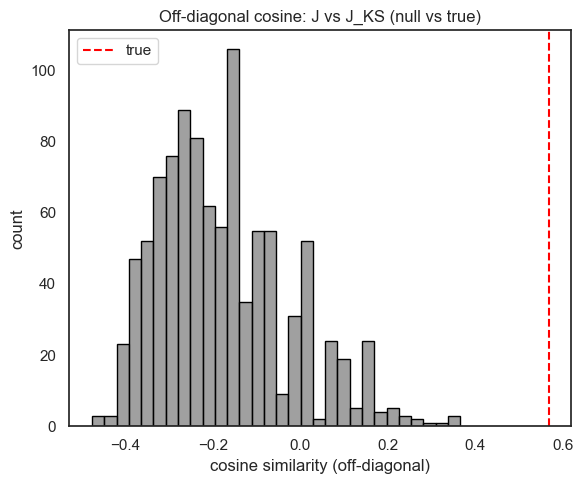

In [41]:
# Off-diagonal cosine similarity: J vs J_KS with a permutation null
J_emp = J_true.copy()
J_emp = 0.5 * (J_emp + J_emp.T)

# Build J_KS from empirical attractors
Xi = A_t.T
N_nodes, K = Xi.shape
C = (A_t @ A_t.T) / N_nodes

eps = 1e-8
try:
    C_inv = np.linalg.inv(C)
except np.linalg.LinAlgError:
    C_inv = np.linalg.pinv(C + eps * np.eye(K))

J_KS_emp = (Xi @ C_inv @ Xi.T) / N_nodes
J_KS_emp = 0.5 * (J_KS_emp + J_KS_emp.T)

mask_off = ~np.eye(N, dtype=bool)

def offdiag_cos(A, B):
    a = A[mask_off]; b = B[mask_off]
    return float(np.dot(a, b) / ((np.linalg.norm(a) + 1e-12) * (np.linalg.norm(b) + 1e-12)))

rho_off_emp = offdiag_cos(J_emp, J_KS_emp)

# Null: permute J, rebuild its own attractors and J_KS, compute off-diagonal cosine

def rho_for_perm(seed, num_starts=200):
    rng = np.random.default_rng(seed)
    vals = J_emp[triu_i, triu_j].copy()
    rng.shuffle(vals)
    Jp = np.zeros_like(J_emp)
    Jp[triu_i, triu_j] = vals
    Jp[triu_j, triu_i] = vals
    np.fill_diagonal(Jp, np.diag(J_emp))
    # attractors
    A_perm = extract_collapsed_attractors(Jp, num_starts=num_starts, beta=_beta_, seed=seed+17)
    if A_perm.size == 0:
        return np.nan
    Xi_p = A_perm.T
    Kp = A_perm.shape[0]
    Cp = (A_perm @ A_perm.T) / N
    try:
        Cpi = np.linalg.inv(Cp)
    except np.linalg.LinAlgError:
        Cpi = np.linalg.pinv(Cp + eps * np.eye(Kp))
    J_KS_p = (Xi_p @ Cpi @ Xi_p.T) / N
    J_KS_p = 0.5 * (J_KS_p + J_KS_p.T)
    return offdiag_cos(Jp, J_KS_p)

num_perms = 1000
rho_off_null = Parallel(n_jobs=-1)(delayed(rho_for_perm)(s) for s in range(num_perms))
rho_off_null = np.array([x for x in rho_off_null if not np.isnan(x)])

p_val = (np.sum(rho_off_null >= rho_off_emp) + 1) / (rho_off_null.size + 1) if rho_off_null.size else np.nan

print(f'Off-diagonal cosine (true): {rho_off_emp:.3f}')
if rho_off_null.size:
    print(f'Null median [IQR]: {np.median(rho_off_null):.3f} '
          f'[{np.percentile(rho_off_null,25):.3f}, {np.percentile(rho_off_null,75):.3f}] (n={rho_off_null.size})')
print(f'p-value (null >= true): {p_val:.3g}')

plt.figure(figsize=(6,5))
sns.histplot(rho_off_null, bins=30, color='gray', edgecolor='black')
plt.axvline(rho_off_emp, color='red', linestyle='--', label='true')
plt.title('Off-diagonal cosine: J vs J_KS (null vs true)')
plt.xlabel('cosine similarity (off-diagonal)'); plt.ylabel('count')
plt.legend(); plt.tight_layout(); plt.show()



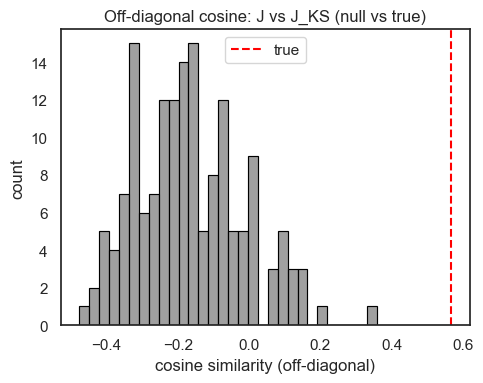

In [40]:
plt.figure(figsize=(5,4))
sns.histplot(rho_off_null, bins=30, color='gray', edgecolor='black')
plt.axvline(rho_off_emp, color='red', linestyle='--', label='true')
plt.title('Off-diagonal cosine: J vs J_KS (null vs true)')
plt.xlabel('cosine similarity (off-diagonal)'); plt.ylabel('count')
plt.legend(); plt.tight_layout(); plt.show()


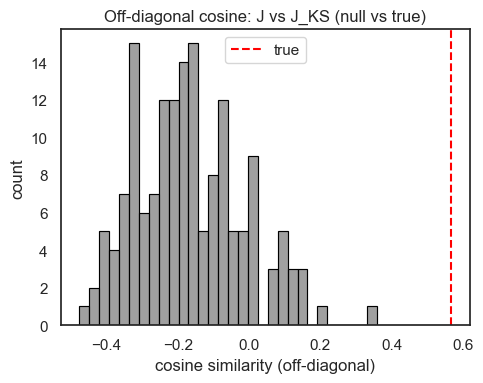

In [ ]:
plt.figure(figsize=(5,4))
sns.histplot(rho_off_null, bins=30, color='gray', edgecolor='black')
plt.axvline(rho_off_emp, color='red', linestyle='--', label='true')
plt.title('Off-diagonal cosine: J vs J_KS (null vs true)')
plt.xlabel('cosine similarity (off-diagonal)'); plt.ylabel('count')
plt.legend(); plt.tight_layout(); plt.show()


Off-diagonal cosine (true): 0.568
Phase-null median [IQR]: -0.159 [-0.222, -0.001] (n=927)
p-value (phase-null >= true): 0.00108


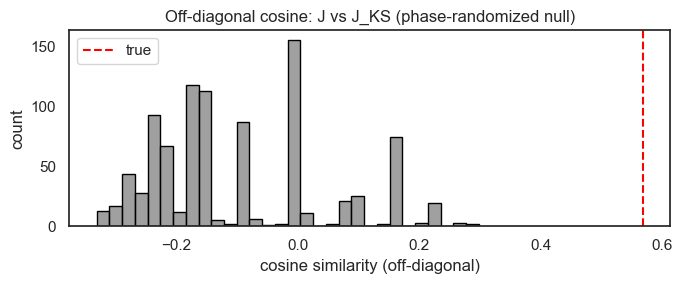

In [20]:
# Off-diagonal cosine similarity: phase-randomized timeseries null (J built from phase-surrogates)
import numpy as np
from nilearn.connectome import ConnectivityMeasure

# Requires: all_ts (list of T x R arrays), N, extract_collapsed_attractors, _beta_, offdiag_cos, J_emp, rho_off_emp
try:
    _ = (all_ts,)
except NameError:
    raise RuntimeError('all_ts not found in this notebook. Load the participant time series before running this cell.')

# Phase-randomize a 1D time series while preserving amplitude spectrum
def phase_randomize_1d(x, rng):
    x = np.asarray(x, dtype=float)
    n = x.shape[0]
    X = np.fft.rfft(x)
    amp = np.abs(X)
    phase = np.angle(X)
    k = X.shape[0]
    start = 1
    end = k - 1
    # keep Nyquist real for even n
    if n % 2 == 0 and k > 1:
        end = k - 2
    if end >= start:
        phase[start:end+1] = rng.uniform(-np.pi, np.pi, size=end - start + 1)
    Xp = amp * np.exp(1j * phase)
    xr = np.fft.irfft(Xp, n=n)
    return xr

# Build a single phase-randomized precision matrix across participants
def build_phase_J(seed):
    rng = np.random.default_rng(seed)
    sur_all = []
    for ts in all_ts:  # T x R per participant
        T, R = ts.shape
        ts_pr = np.empty_like(ts)
        for r in range(R):
            ts_pr[:, r] = phase_randomize_1d(ts[:, r], rng)
        sur_all.append(ts_pr)
    cm = ConnectivityMeasure(kind='precision', vectorize=False, discard_diagonal=False)
    cm.fit_transform(sur_all)
    Jp = -1 * cm.mean_  # match sign convention used previously
    return Jp

# For each surrogate J, compute its own attractors, J_KS, and off-diagonal cosine

def rho_for_phase(seed):
    Jp = build_phase_J(seed)
    A_p = extract_collapsed_attractors(Jp, num_starts=200, beta=_beta_, seed=seed+123)
    if A_p.size == 0:
        return np.nan
    Xi_p = A_p.T
    Kp = A_p.shape[0]
    Cp = (A_p @ A_p.T) / N
    try:
        Cpi = np.linalg.inv(Cp)
    except np.linalg.LinAlgError:
        Cpi = np.linalg.pinv(Cp + 1e-8 * np.eye(Kp))
    J_KS_p = (Xi_p @ Cpi @ Xi_p.T) / N
    J_KS_p = 0.5 * (J_KS_p + J_KS_p.T)
    return offdiag_cos(Jp, J_KS_p)

num_phase = 1000
rho_off_phase = Parallel(n_jobs=-1)(delayed(rho_for_phase)(s) for s in range(num_phase))
rho_off_phase = np.array([x for x in rho_off_phase if not np.isnan(x)])

p_val_phase = (np.sum(rho_off_phase >= rho_off_emp) + 1) / (rho_off_phase.size + 1) if rho_off_phase.size else np.nan

print(f'Off-diagonal cosine (true): {rho_off_emp:.3f}')
if rho_off_phase.size:
    print(f'Phase-null median [IQR]: {np.median(rho_off_phase):.3f} '
          f'[{np.percentile(rho_off_phase,25):.3f}, {np.percentile(rho_off_phase,75):.3f}] (n={rho_off_phase.size})')
print(f'p-value (phase-null >= true): {p_val_phase:.3g}')

plt.figure(figsize=(7,3))
sns.histplot(rho_off_phase, bins=30, color='gray', edgecolor='black')
plt.axvline(rho_off_emp, color='red', linestyle='--', label='true')
plt.title('Off-diagonal cosine: J vs J_KS (phase-randomized null)')
plt.xlabel('cosine similarity (off-diagonal)'); plt.ylabel('count')
plt.legend(); plt.tight_layout(); plt.show()
